<a href="https://colab.research.google.com/github/pyafv/assets/blob/main/jupyter/periodic_plotting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pyafv

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pyafv as afv

## Open boundary conditions

The code uses open boundary conditions.

In [3]:
np.random.seed(42)

N = 1000                    # number of cells         
L = 40                      # box size
pts = np.random.rand(N, 2)  # shape (N,2)
pts *= L

In [4]:
# Maximal radius
radius = 1.0

# Parameter set
phys = afv.PhysicalParams(
    r=radius,
)

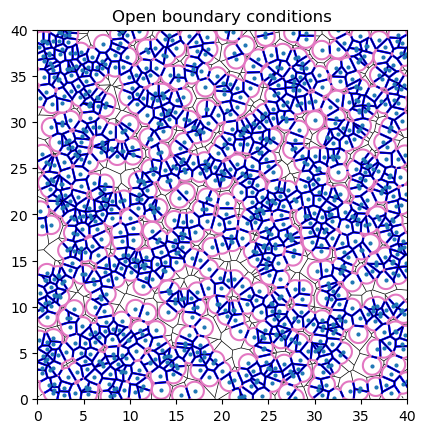

In [5]:
sim = afv.FiniteVoronoiSimulator(pts, phys)

fig, ax = plt.subplots(dpi=100)
ax = sim.plot_2d()

ax.set_xlim(0, L)
ax.set_ylim(0, L)
ax.set_title("Open boundary conditions")

plt.show()

## Periodic boundary conditions

It's simple to achieve the periodic boundary boundary via a tiling of the edge regions (at least $2\ell$).

> The following tiling routine is now wrapped as a utility function `pyafv.tile_pbc`.

In [6]:
def tile_pbc_with_index(pts: np.ndarray, r: float, L: float):
    """
    Periodic tiling of pts (N,2), with bookkeeping.
    Returns:
        pos_pbc  : (M,2) tiled positions
        idx_orig : (M,) indices mapping each tiled point back to original 0..N-1
    """
    pts = np.asarray(pts)
    N = pts.shape[0]
    thresh = 2.01 * r

    x = pts[:, 0]
    y = pts[:, 1]

    # --- Stage 1: originals + left/right ---
    mask_l = x <= thresh
    mask_r = x >= (L - thresh)
    inds_l = np.flatnonzero(mask_l)
    inds_r = np.flatnonzero(mask_r)
    n_l, n_r = inds_l.size, inds_r.size

    NA = N + n_l + n_r
    pos_aug = np.empty((NA, 2), dtype=pts.dtype)
    idx_aug = np.empty(NA, dtype=np.int64)

    # originals
    pos_aug[:N] = pts
    idx_aug[:N] = np.arange(N, dtype=np.int64)
    i = N

    # left (+L, 0)
    if n_l:
        sl = slice(i, i+n_l)
        pos_aug[sl] = pts[inds_l]
        pos_aug[sl, 0] += L
        idx_aug[sl] = inds_l
        i += n_l

    # right (−L, 0)
    if n_r:
        sl = slice(i, i+n_r)
        pos_aug[sl] = pts[inds_r]
        pos_aug[sl, 0] -= L
        idx_aug[sl] = inds_r
        i += n_r

    # --- Stage 2: on augmented, append down then up ---
    y_aug = pos_aug[:, 1]
    inds_d = np.flatnonzero(y_aug <= thresh)
    inds_u = np.flatnonzero(y_aug >= (L - thresh))
    n_d, n_u = inds_d.size, inds_u.size

    M = NA + n_d + n_u
    pos_out = np.empty((M, 2), dtype=pts.dtype)
    idx_out = np.empty(M, dtype=np.int64)

    pos_out[:NA] = pos_aug
    idx_out[:NA] = idx_aug
    j = NA

    # down (0, +L)
    if n_d:
        sl = slice(j, j+n_d)
        pos_out[sl] = pos_aug[inds_d]
        pos_out[sl, 1] += L
        idx_out[sl] = idx_aug[inds_d]
        j += n_d

    # up (0, −L)
    if n_u:
        sl = slice(j, j+n_u)
        pos_out[sl] = pos_aug[inds_u]
        pos_out[sl, 1] -= L
        idx_out[sl] = idx_aug[inds_u]

    return pos_out, idx_out

In [7]:
# pts_pbc, idx_pbc = tile_pbc_with_index(pts, radius, L)
pts_pbc, idx_pbc = afv.tile_pbc(pts, L, radius)  # note that the function name and argument order in this utility function differ slightly.
sim.update_positions(pts_pbc)

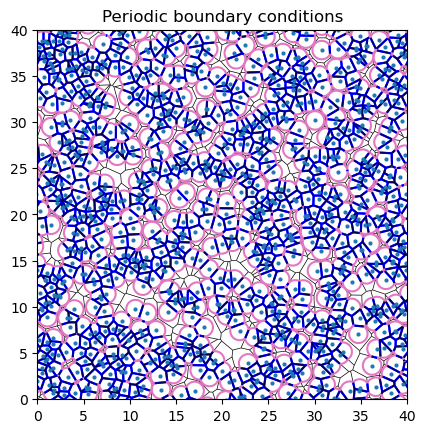

In [8]:
fig, ax = plt.subplots(dpi=100)
ax = sim.plot_2d()

ax.set_xlim(0, L)
ax.set_ylim(0, L)
ax.set_title("Periodic boundary conditions")

plt.show()

### Custom plotting functions (serial and vectorized)

> **Important:** You can skip the two function definitions below - we have already wrapped the fast vectorized routine up as a standalone function `pyafv.visualize_2d`.

In [9]:
def custom_plot_2d(pts: np.ndarray, diag: dict, r: float, ax=None):
    """
    Custom plot function
    """
    if ax is None:
        ax = plt.gca()

    point_edges_type = diag["edges_type"]
    point_vertices_f_idx = diag["regions"]
    vertices_all = diag["vertices"]

    # Draw cell centers
    # ax.plot(pts[:, 0], pts[:, 1], 'o', color='C0', markersize=2, zorder=3)

    N = len(pts)

    # Draw each cell boundary
    for idx in range(N):
        edges_type = point_edges_type[idx]
        vertices_f_idx = point_vertices_f_idx[idx]

        x, y = pts[idx]
        if len(edges_type) < 2:
            angle = np.linspace(0, 2*np.pi, 100)
            ax.plot(x + r * np.cos(angle), y + r *
                    np.sin(angle), color="C2", lw=1., zorder=1)
            ax.fill(x + r * np.cos(angle), y + r * np.sin(angle),
                    color="C2", alpha=0.1, lw=0, zorder=0)
            continue

        boundary_x = []
        boundary_y = []
        for idx_f, edge_type in enumerate(edges_type):
            v1_idx = vertices_f_idx[idx_f]
            x1, y1 = vertices_all[v1_idx]
            idx2 = idx_f + 1 if idx_f < len(edges_type)-1 else 0
            v2_idx = vertices_f_idx[idx2]
            x2, y2 = vertices_all[v2_idx]

            if edge_type == 1:
                ax.plot([x1, x2], [y1, y2], color="C0", lw=1., zorder=2)
                boundary_x.append(x2)
                boundary_y.append(y2)
            else:
                angle1 = np.arctan2(y1-y, x1-x)
                angle2 = np.arctan2(y2-y, x2-x)
                dangle = np.linspace(0, (angle1 - angle2) % (2*np.pi), 100)

                xr = x + r * np.cos(angle1 - dangle)
                yr = y + r * np.sin(angle1 - dangle)
                boundary_x.extend(xr)
                boundary_y.extend(yr)
                ax.plot(xr, yr, color="C2", lw=1., zorder=1)

        ax.fill(boundary_x, boundary_y, color="C2", alpha=0.1, lw=0, zorder=0)

    ax.set_aspect("equal")
    return ax


from matplotlib.collections import LineCollection, PolyCollection


def custom_plot_2d_fast(pts: np.ndarray, diag: dict, r: float, ax=None):
    """
    Faster custom plot function (vectorized version)
    
    You can skip this part - it is just an opaque, vectorized reimplementation of the function above.
    The speedup is especially noticeable when plotting large-N systems and generating many frames for videos.
    """
    if ax is None:
        ax = plt.gca()

    point_edges_type = diag["edges_type"]
    point_vertices_f_idx = diag["regions"]
    vertices_all = diag["vertices"]
    N = len(pts)

    cell_colors = ["C2"] * N

    # --- Classify cells ---
    cell_lens = np.fromiter((len(et) for et in point_edges_type), dtype=int, count=N)
    deg_mask = cell_lens < 2
    valid_mask = ~deg_mask

    # --- Per-edge geometry (vectorized) ---
    straight_segs = None
    arc_xy = None
    valid_cells_idx = None
    offsets = None
    flat_e = None
    edge_to_arc = None
    straight_pts = None

    if valid_mask.any():
        valid_cells_idx = np.where(valid_mask)[0]
        valid_lens = cell_lens[valid_mask]

        flat_v = np.concatenate([np.asarray(point_vertices_f_idx[i], dtype=int) for i in valid_cells_idx])
        flat_e = np.concatenate([np.asarray(point_edges_type[i], dtype=int) for i in valid_cells_idx])
        flat_cell = np.repeat(valid_cells_idx, valid_lens)

        offsets = np.concatenate(([0], np.cumsum(valid_lens)))
        next_idx = np.arange(flat_v.size) + 1
        next_idx[offsets[1:] - 1] = offsets[:-1]
        flat_v2 = flat_v[next_idx]

        straight_mask = flat_e == 1
        arc_mask = flat_e == 0

        if straight_mask.any():
            straight_segs = np.stack([vertices_all[flat_v[straight_mask]], vertices_all[flat_v2[straight_mask]]], axis=1)

        straight_pts = vertices_all[flat_v2]   # (E, 2); consumed only at straight positions

        if arc_mask.any():
            centers = pts[flat_cell[arc_mask]]
            V1a = vertices_all[flat_v[arc_mask]]
            V2a = vertices_all[flat_v2[arc_mask]]
            angle1 = np.arctan2(V1a[:, 1] - centers[:, 1], V1a[:, 0] - centers[:, 0])
            angle2 = np.arctan2(V2a[:, 1] - centers[:, 1], V2a[:, 0] - centers[:, 0])
            total = (angle1 - angle2) % (2 * np.pi)
            t = np.linspace(0.0, 1.0, 100)
            theta = angle1[:, None] - t[None, :] * total[:, None]        # v1 -> v2
            arc_xy = np.stack([centers[:, 0:1] + r * np.cos(theta), centers[:, 1:2] + r * np.sin(theta)], axis=-1)  # (A, 100, 2)

            edge_to_arc = np.full(flat_e.size, -1, dtype=int)
            edge_to_arc[arc_mask] = np.arange(arc_mask.sum())

    # --- Full-circle polylines for degenerate cells ---
    deg_circles = None
    deg_idx = None
    if deg_mask.any():
        deg_idx = np.where(deg_mask)[0]
        th = np.linspace(0.0, 2 * np.pi, 100)
        circle_template = np.column_stack([np.cos(th), np.sin(th)])      # (100, 2)
        deg_circles = pts[deg_idx, None, :] + r * circle_template[None, :, :]   # (D, 100, 2)

    # --- Assemble per-cell fill polygons (ragged list) ---
    polygons = []
    face_colors = []

    if valid_mask.any():
        for c_idx, c in enumerate(valid_cells_idx):
            s, e = offsets[c_idx], offsets[c_idx + 1]
            parts = [straight_pts[p:p+1] if flat_e[p] == 1 else arc_xy[edge_to_arc[p]] for p in range(s, e)]
            polygons.append(np.concatenate(parts, axis=0))
            face_colors.append(cell_colors[c])

    if deg_circles is not None:
        for k, c in enumerate(deg_idx):
            polygons.append(deg_circles[k])
            face_colors.append(cell_colors[c])

    # --- Emit collections ---
    # Fills (zorder=0)
    if polygons:
        ax.add_collection(PolyCollection(polygons, facecolors=face_colors, alpha=0.1, linewidths=0, zorder=0))

    # Straight strokes (zorder=2)
    if straight_segs is not None:
        ax.add_collection(LineCollection(straight_segs, colors="C0", lw=1.0, zorder=2))

    # Arc + full-circle strokes (zorder=1)
    arc_polylines = []
    if arc_xy is not None:
        arc_polylines.append(arc_xy)
    if deg_circles is not None:
        arc_polylines.append(deg_circles)
    if arc_polylines:
        ax.add_collection(LineCollection(np.concatenate(arc_polylines, axis=0), colors="C2", lw=1.0, zorder=1))

    ax.set_aspect("equal")
    return ax

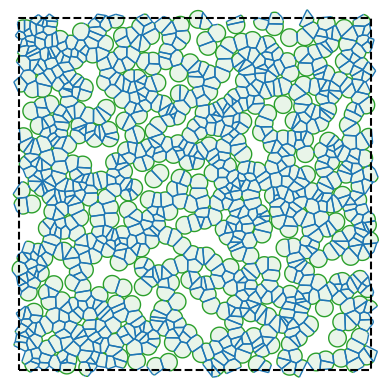

In [10]:
diag = sim.build()

# Plot the first N cells
fig, ax = plt.subplots(dpi=100)

"""
Three plotting options are provided:
    1. The serial implementation: `custom_plot_2d`
    2. The vectorized (faster) implementation: `custom_plot_2d_fast`
    3. The standalone wrapper `pyafv.visualize_2d`, which builds on the vectorized implementation (2)
"""
# ax = custom_plot_2d(pts, diag, radius)
# ax = custom_plot_2d_fast(pts, diag, radius)
afv.visualize_2d(pts, diag, radius, ax=ax)

ax.tick_params(axis='both', length=0, labelbottom=False, labelleft=False)
ax.axis('off')   # <- hides ticks, labels, and spines

ax.plot([0, L, L, 0, 0], [0, 0, L, L, 0], 'k--')
ax.set_xlim(-radius, L+radius)
ax.set_ylim(-radius, L+radius)
# plt.savefig('pbc.png', dpi=300, bbox_inches='tight')

plt.show()

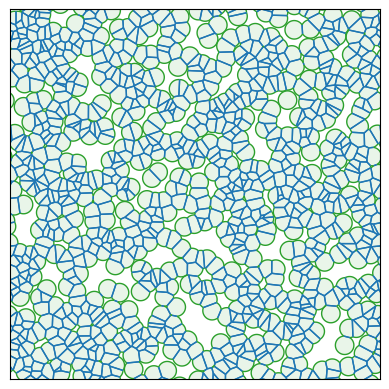

In [11]:
# Plot all cells
fig, ax = plt.subplots(dpi=100)

# ax = custom_plot_2d(pts_pbc, diag, radius)
# ax = custom_plot_2d_fast(pts_pbc, diag, radius)
afv.visualize_2d(pts_pbc, diag, radius, ax=ax)

ax.tick_params(axis='both', length=0, labelbottom=False, labelleft=False)
ax.set_xlim(0, L)
ax.set_ylim(0, L)
plt.show()

## Simulation video preview

![AFV](../gif/test.gif)